In [1]:
# ============================================
# CELL 1: Imports
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (accuracy_score, precision_score, 
                              recall_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve)
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
# ============================================
# CELL 2: Load Data & Models
# ============================================
# Load test data
X_test_int = np.load(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\X_test_int.npy')
y_test_int = np.load(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\y_test_int.npy')
X_test_phi = np.load(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\X_test_phi.npy')
y_test_phi = np.load(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\y_test_phi.npy')

# Load all models
path = r'C:\Users\Kshaunish\cyber-xai-ml-project\models\saved_models\\'
lr_int  = joblib.load(path + 'lr_intrusion.pkl')
dt_int  = joblib.load(path + 'dt_intrusion.pkl')
rf_int  = joblib.load(path + 'rf_intrusion.pkl')
xgb_int = joblib.load(path + 'xgb_intrusion.pkl')
ens_int = joblib.load(path + 'ensemble_intrusion.pkl')

lr_phi  = joblib.load(path + 'lr_phishing.pkl')
dt_phi  = joblib.load(path + 'dt_phishing.pkl')
rf_phi  = joblib.load(path + 'rf_phishing.pkl')
xgb_phi = joblib.load(path + 'xgb_phishing.pkl')
ens_phi = joblib.load(path + 'ensemble_phishing.pkl')

print("✅ All data and models loaded!")

✅ All data and models loaded!


In [3]:
# ============================================
# CELL 3: Full Metrics Table
# ============================================
models_int = {
    'Logistic Regression': lr_int,
    'Decision Tree': dt_int,
    'Random Forest': rf_int,
    'XGBoost': xgb_int,
    'RF+XGBoost Ensemble': ens_int
}

models_phi = {
    'Logistic Regression': lr_phi,
    'Decision Tree': dt_phi,
    'Random Forest': rf_phi,
    'XGBoost': xgb_phi,
    'RF+XGBoost Ensemble': ens_phi
}

def get_metrics(model, X_test, y_test, multi=False):
    y_pred = model.predict(X_test)
    avg = 'weighted' if multi else 'binary'
    return {
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred, average=avg) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred, average=avg) * 100, 2),
        'F1 Score':  round(f1_score(y_test, y_pred, average=avg) * 100, 2),
    }

# Intrusion metrics
print("=" * 65)
print("INTRUSION DETECTION RESULTS")
print("=" * 65)
int_results = []
for name, model in models_int.items():
    metrics = get_metrics(model, X_test_int, y_test_int, multi=True)
    metrics['Model'] = name
    int_results.append(metrics)

int_df = pd.DataFrame(int_results)[['Model','Accuracy','Precision','Recall','F1 Score']]
print(int_df.to_string(index=False))

# Phishing metrics
print("\n" + "=" * 65)
print("PHISHING DETECTION RESULTS")
print("=" * 65)
phi_results = []
for name, model in models_phi.items():
    metrics = get_metrics(model, X_test_phi, y_test_phi, multi=False)
    metrics['Model'] = name
    phi_results.append(metrics)

phi_df = pd.DataFrame(phi_results)[['Model','Accuracy','Precision','Recall','F1 Score']]
print(phi_df.to_string(index=False))

# Save both tables
int_df.to_csv(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\intrusion_metrics.csv', index=False)
phi_df.to_csv(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\phishing_metrics.csv', index=False)
print("\n✅ Metrics saved!")

INTRUSION DETECTION RESULTS
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression     98.14      98.42   98.14     98.22
      Decision Tree     99.91      99.91   99.91     99.91
      Random Forest     99.94      99.94   99.94     99.94
            XGBoost     99.95      99.95   99.95     99.95
RF+XGBoost Ensemble     99.95      99.95   99.95     99.95

PHISHING DETECTION RESULTS
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression     99.99      99.98   100.0     99.99
      Decision Tree    100.00     100.00   100.0    100.00
      Random Forest    100.00     100.00   100.0    100.00
            XGBoost    100.00     100.00   100.0    100.00
RF+XGBoost Ensemble    100.00     100.00   100.0    100.00

✅ Metrics saved!


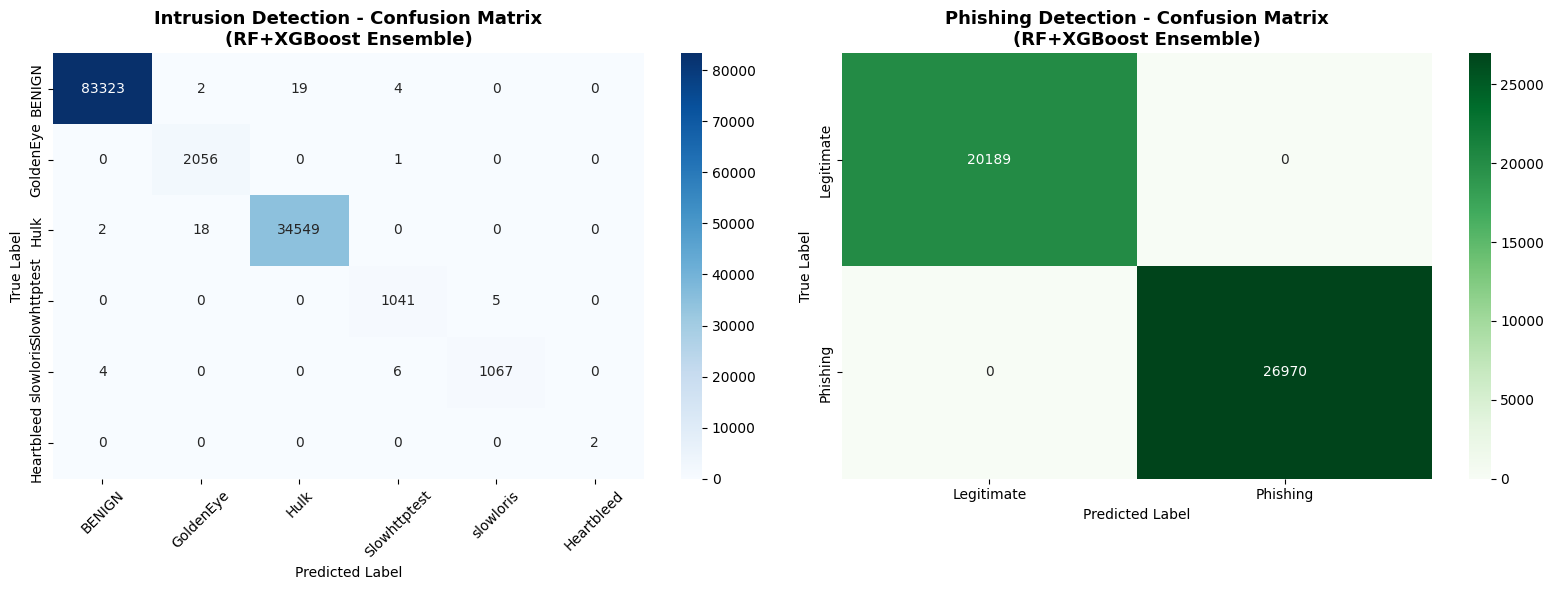

✅ Confusion matrices saved!


In [4]:
# ============================================
# CELL 4: Confusion Matrix - Ensemble Models
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Intrusion confusion matrix
cm_int = confusion_matrix(y_test_int, ens_int.predict(X_test_int))
sns.heatmap(cm_int, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['BENIGN','GoldenEye','Hulk','Slowhttptest','slowloris','Heartbleed'],
            yticklabels=['BENIGN','GoldenEye','Hulk','Slowhttptest','slowloris','Heartbleed'])
axes[0].set_title('Intrusion Detection - Confusion Matrix\n(RF+XGBoost Ensemble)', 
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=45)

# Phishing confusion matrix
cm_phi = confusion_matrix(y_test_phi, ens_phi.predict(X_test_phi))
sns.heatmap(cm_phi, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
axes[1].set_title('Phishing Detection - Confusion Matrix\n(RF+XGBoost Ensemble)',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved!")

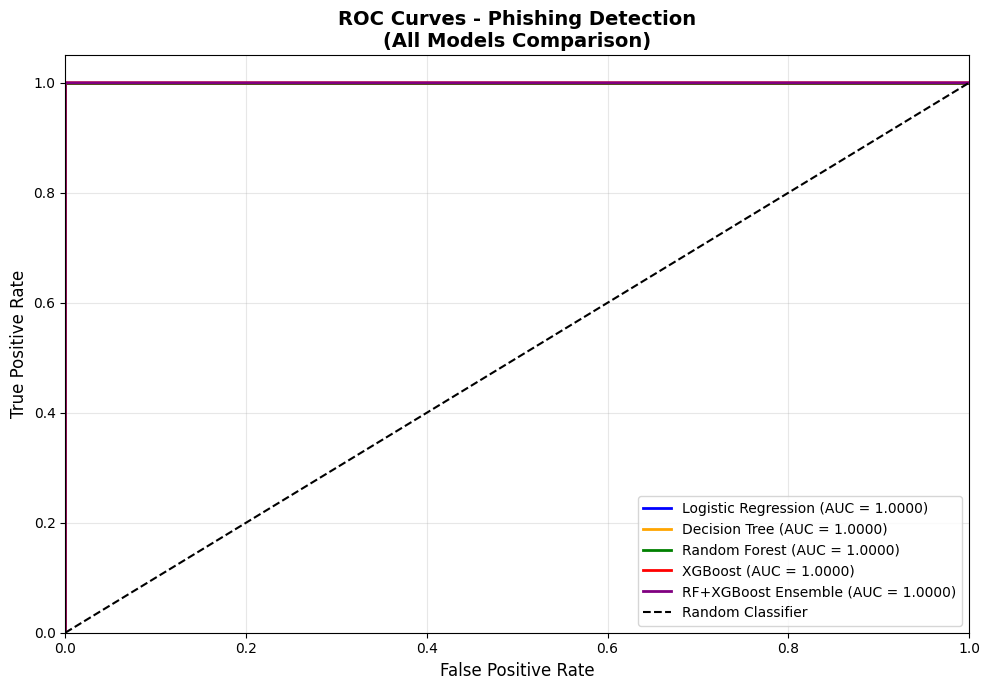

✅ ROC curves saved!


In [5]:
# ============================================
# CELL 5: ROC Curves - Phishing Dataset
# ============================================
from sklearn.preprocessing import label_binarize

plt.figure(figsize=(10, 7))

models_roc = {
    'Logistic Regression': lr_phi,
    'Decision Tree': dt_phi,
    'Random Forest': rf_phi,
    'XGBoost': xgb_phi,
    'RF+XGBoost Ensemble': ens_phi
}

colors = ['blue', 'orange', 'green', 'red', 'purple']

for (name, model), color in zip(models_roc.items(), colors):
    y_prob = model.predict_proba(X_test_phi)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_phi, y_prob)
    auc = roc_auc_score(y_test_phi, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Phishing Detection\n(All Models Comparison)', 
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\roc_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC curves saved!")

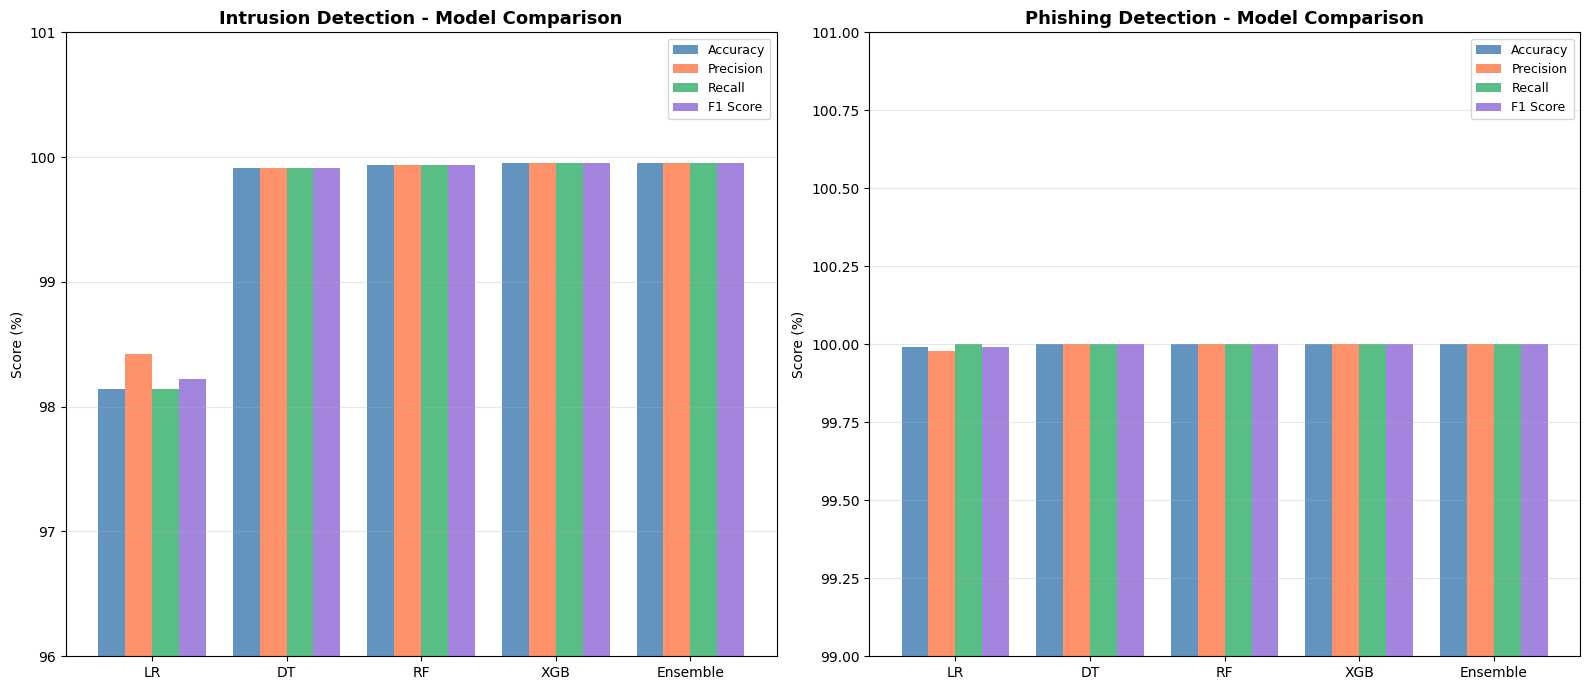

✅ Metrics comparison chart saved!


In [6]:
# ============================================
# CELL 6: Metrics Comparison Bar Chart
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

models_names = ['LR', 'DT', 'RF', 'XGB', 'Ensemble']
x = np.arange(len(models_names))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

# Intrusion chart
for i, (metric, color) in enumerate(zip(metrics, colors)):
    axes[0].bar(x + i*width, int_df[metric], width, 
                label=metric, color=color, alpha=0.85)
axes[0].set_title('Intrusion Detection - Model Comparison',
                   fontsize=13, fontweight='bold')
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(models_names)
axes[0].set_ylabel('Score (%)')
axes[0].set_ylim([96, 101])
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Phishing chart
for i, (metric, color) in enumerate(zip(metrics, colors)):
    axes[1].bar(x + i*width, phi_df[metric], width,
                label=metric, color=color, alpha=0.85)
axes[1].set_title('Phishing Detection - Model Comparison',
                   fontsize=13, fontweight='bold')
axes[1].set_xticks(x + width*1.5)
axes[1].set_xticklabels(models_names)
axes[1].set_ylabel('Score (%)')
axes[1].set_ylim([99, 101])
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\metrics_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Metrics comparison chart saved!")